In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv('forest_fires_train.csv')

X = df.drop(columns = ["big_fire"])
y = df["big_fire"]

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score


#use balanced because the frequency in dataset differs by more than 
#65/35 (was about 85/15)
#use max_features sqrt to help with diversity and generalization, helps with correlation

rf = RandomForestClassifier(n_estimators = 350, max_depth = None,
        min_samples_leaf = 2, max_features = "sqrt", class_weight = "balanced", random_state = 1)

#stratified kfold helps with maintaining
#the distribution for big firess in the dataset 
#so each fold should be ~84% zeros and ~16% ones

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)


scores = cross_val_score(rf, X, y, cv = cv, scoring = "roc_auc")

print("Mean AUC:", scores.mean())
print("Std AUC:", scores.std())

Mean AUC: 0.8829203668528034
Std AUC: 0.0017048581522622662


In [4]:
rf.fit(X, y)

feat_imp = pd.Series(rf.feature_importances_, index = X.columns)
feat_imp.sort_values(ascending = False)

long                0.222829
lat                 0.120379
Hum_30              0.091089
Hum_15              0.089528
Hum_7               0.067925
dist_met_station    0.064833
Temp_7              0.048755
Wind_30             0.047460
Temp_15             0.046886
Temp_30             0.046541
Wind_15             0.044732
Wind_7              0.042398
Prcp_30             0.031513
Prcp_15             0.020702
Prcp_7              0.014430
dtype: float64

Text(0.5, 1.0, 'Random Forest Variable Importance')

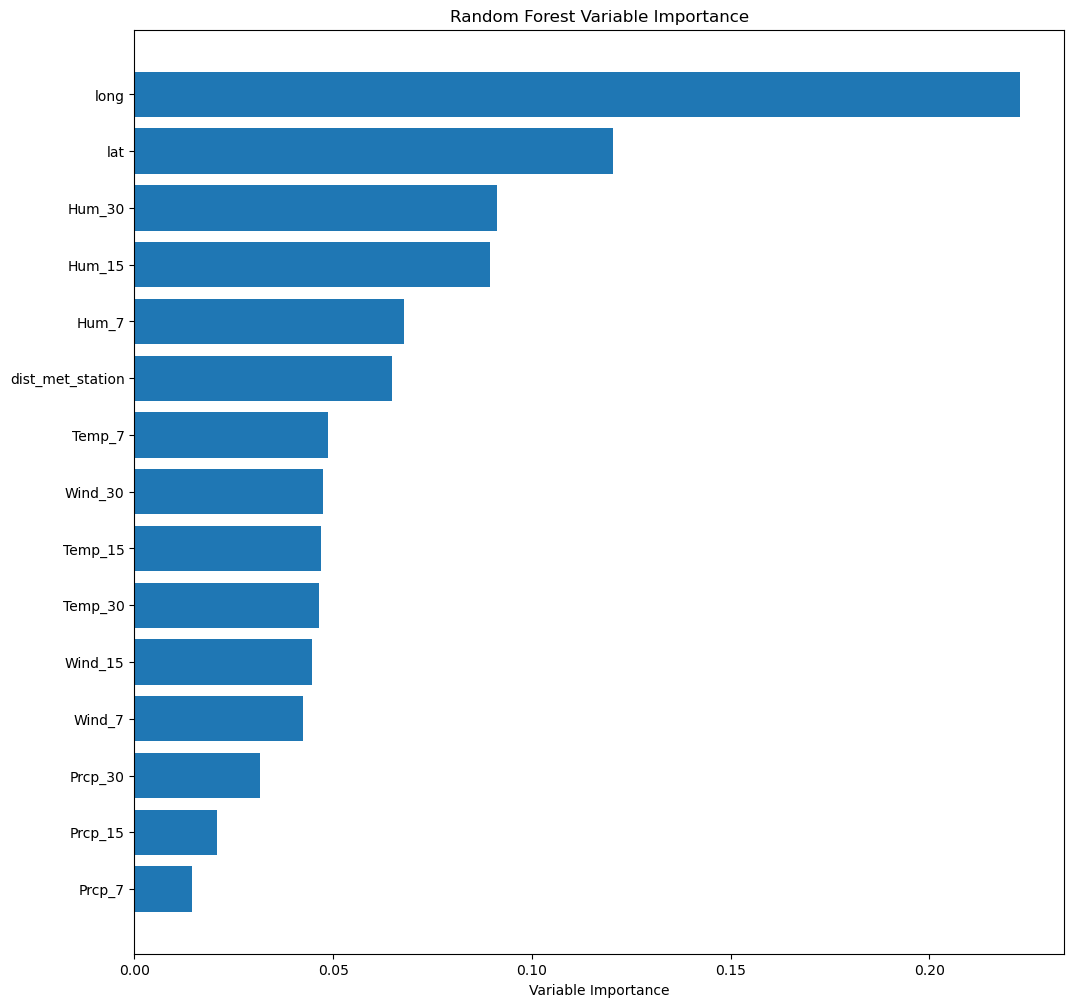

In [5]:
#Store importances
importances = rf.feature_importances_
names = X.columns

#Sort importances to be plotted with
#the predictor names
index = np.argsort(importances)
sorted_importances = importances[index]
sorted_names = names[index]

#Plot creation code
plt.figure(figsize = (12,12))
plt.barh(sorted_names, sorted_importances)
plt.xlabel('Variable Importance')
plt.title('Random Forest Variable Importance')

In [6]:
X_no_space = X.drop(columns=["lat", "long"])

scores_no_space = cross_val_score(rf, X_no_space, y, cv = cv,
                scoring = "roc_auc", n_jobs = -1)

print(scores_no_space.mean(), scores_no_space.std())

0.8294848141460036 0.00983436998275098


In [8]:
#test without temperature

X_no_temp = X.drop(columns=["Prcp_30", "Prcp_15" ,"Prcp_7"])

scores_no_temp = cross_val_score(rf, X_no_temp, y, cv = cv,
                scoring = "roc_auc", n_jobs = -1)

print(scores_no_temp.mean(), scores_no_temp.std())

0.8853392467132707 0.0023841057466395797


Found this interesting, dropping lat and long had a notable impact.  

In [36]:
#tried to play around with different trends
#could probably come back to this to try and establish
#different links between variables, proxies, etc.

df_fe = df.copy()

#Humidity trend
df_fe["Hum_drop"] = df_fe["Hum_30"] - df_fe["Hum_7"]

#Temperature trend
df_fe["Temp_rise"] = df_fe["Temp_7"] - df_fe["Temp_30"]

#Define new feature matrices
X_fe = df_fe.drop(columns = ["big_fire"])
X_fe_no_space = X_fe.drop(columns = ["lat", "long"])
y_fe = df_fe["big_fire"]

In [37]:
scores_fe = cross_val_score(rf, X_fe, y_fe, cv = cv,
            scoring = "roc_auc", n_jobs = -1)

print("Extra features Mean AUC:", scores_fe.mean())
print("Extra features Std AUC:", scores_fe.std())

Extra features Mean AUC: 0.8842067495418894
Extra features Std AUC: 0.003245485317986345


In [38]:
scores_fe_no_space = cross_val_score(rf, X_fe_no_space, y_fe, 
        cv = cv, scoring = "roc_auc", n_jobs = -1)

print("Added feature (No spatial) Mean AUC:", scores_fe_no_space.mean())
print("Added feature (No spatial) Std AUC:", scores_fe_no_space.std())

Added feature (No spatial) Mean AUC: 0.8319069152064176
Added feature (No spatial) Std AUC: 0.01065407436746966


In [39]:
f1_scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("Mean F1:", f1_scores.mean())
print("Std F1:", f1_scores.std())

Mean F1: 0.5820866690716889
Std F1: 0.005298269605089842


In [40]:
f1_scores = cross_val_score(
    rf,
    X_fe,
    y_fe,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("Mean F1:", f1_scores.mean())
print("Std F1:", f1_scores.std())

Mean F1: 0.5817498124060703
Std F1: 0.0099509651051268


In [41]:
f1_scores_no_space = cross_val_score(
    rf,
    X_no_space,
    y,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("No-space Mean F1:", f1_scores_no_space.mean())
print("No-space Std F1:", f1_scores_no_space.std())

No-space Mean F1: 0.487226322382622
No-space Std F1: 0.010538696737538818


In [42]:
param_grid = {
    "max_depth": [None, 20, 40],
    "min_samples_leaf": [5, 10, 20],
    "n_estimators": [350, 500, 750]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X, y)

print("Best params:", grid.best_params_)
print("Best AUC:", grid.best_score_)

Best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 350}
Best AUC: 0.8836830683641128


In [43]:

param_grid = {
    "max_depth": [None],
    "min_samples_leaf": [4, 5, 6, 7, 8],
    "n_estimators": [300, 350, 400]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X, y)

print("Best params:", grid.best_params_)
print("Best AUC:", grid.best_score_)

Best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 350}
Best AUC: 0.8836830683641128


In [44]:
rf_best = RandomForestClassifier(
    n_estimators=350,
    max_depth=None,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=1,
)

In [45]:
# First split: 80 train, 20 temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=1
)

# Second split: split temp into 10/10
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=1
)

In [46]:
#original model
rf.fit(X_train, y_train)

# Validation
val_probs = rf.predict_proba(X_val)[:, 1]
val_preds = (val_probs >= 0.5).astype(int)

print("Validation AUC:", roc_auc_score(y_val, val_probs))
print("Validation F1:", f1_score(y_val, val_preds))

# Test
test_probs = rf.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

print("Test AUC:", roc_auc_score(y_test, test_probs))
print("Test F1:", f1_score(y_test, test_preds))

Validation AUC: 0.8696474254820751
Validation F1: 0.5560538116591929
Test AUC: 0.8813886173924718
Test F1: 0.5701754385964912


In [47]:
#optimized model
rf_best.fit(X_train, y_train)

print("Tuned model results:")

# Validation
val_probs = rf_best.predict_proba(X_val)[:, 1]
val_preds = (val_probs >= 0.5).astype(int)

print("Validation AUC:", roc_auc_score(y_val, val_probs))
print("Validation F1:", f1_score(y_val, val_preds))

# Test
test_probs = rf_best.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

print("Test AUC:", roc_auc_score(y_test, test_probs))
print("Test F1:", f1_score(y_test, test_preds))

Tuned model results:
Validation AUC: 0.867608588459806
Validation F1: 0.5815423514538559
Test AUC: 0.8784326173774157
Test F1: 0.5989974937343359


In [50]:
# Fit baseline
rf.fit(X_train, y_train)

# Predict
val_probs_base = rf.predict_proba(X_val)[:, 1]
val_preds_base = (val_probs_base >= 0.5).astype(int)

# Report
print("Baseline Model Classification Report:")
print(classification_report(y_val, val_preds_base))

Baseline Model Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      2081
           1       0.65      0.49      0.56       383

    accuracy                           0.88      2464
   macro avg       0.78      0.72      0.74      2464
weighted avg       0.87      0.88      0.87      2464



In [51]:
# Fit tuned model
rf_best.fit(X_train, y_train)

# Predict
val_probs_best = rf_best.predict_proba(X_val)[:, 1]
val_preds_best = (val_probs_best >= 0.5).astype(int)

# Report
print("Tuned Model Classification Report:")
print(classification_report(y_val, val_preds_best))

Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      2081
           1       0.56      0.60      0.58       383

    accuracy                           0.87      2464
   macro avg       0.74      0.76      0.75      2464
weighted avg       0.87      0.87      0.87      2464



**The following section is for engineered features**

In [52]:
#engineered features exploration


X_fe_train, X_fe_temp, y_fe_train, y_fe_temp = train_test_split(
    X_fe,
    y_fe,
    test_size=0.2,
    stratify=y_fe,
    random_state=1
)

X_fe_val, X_fe_test, y_fe_val, y_fe_test = train_test_split(
    X_fe_temp,
    y_fe_temp,
    test_size=0.5,
    stratify=y_fe_temp,
    random_state=1
)

In [53]:
rf_best.fit(X_fe_train, y_fe_train)

# Validation
val_probs_fe = rf_best.predict_proba(X_fe_val)[:, 1]
val_preds_fe = (val_probs_fe >= 0.5).astype(int)

print("FE Validation AUC:", roc_auc_score(y_fe_val, val_probs_fe))
print("FE Validation F1:", f1_score(y_fe_val, val_preds_fe))

# Test
test_probs_fe = rf_best.predict_proba(X_fe_test)[:, 1]
test_preds_fe = (test_probs_fe >= 0.5).astype(int)

print("FE Test AUC:", roc_auc_score(y_fe_test, test_probs_fe))
print("FE Test F1:", f1_score(y_fe_test, test_preds_fe))

FE Validation AUC: 0.8682873643546045
FE Validation F1: 0.5824742268041238
FE Test AUC: 0.8787237005707489
FE Test F1: 0.6040609137055838


In [56]:


print("Feature Engineered Validation Report:")
print(classification_report(y_fe_val, val_preds_fe))

Feature Engineered Validation Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2081
           1       0.58      0.59      0.58       383

    accuracy                           0.87      2464
   macro avg       0.75      0.75      0.75      2464
weighted avg       0.87      0.87      0.87      2464

